# 📘 TaaSim — Remapping Porto → Casablanca (Version Finale)

**Pipeline complet :**
1. Setup Spark + chargement données
2. Chargement GeoJSON Casa + poids population par zone
3. Calcul BBOX Porto
4. Remapping linéaire Porto → Casa (`remap_udf`)
5. Translation pondérée population vers zone Casa (`translate_udf`)
6. Snap au graphe routier OSM (`snap_to_road`)
7. Calcul `origin_zone`, `dest_zone`, `trip_duration`, `year_month`
8. Validation distribution par zone
9. Visualisation heatmap + trajets snappés
10. Sauvegarde `s3a://curated/porto-trips/` (Parquet, partitionné `year_month`)

## ⚙️ CELLULE 0 — Installations

In [1]:
!pip install -r /home/jovyan/requirements.txt -q
!pip install geopandas shapely folium osmnx networkx -q


## 🚀 CELLULE 1 — Initialisation Spark

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
import pandas as pd
import folium
import json

spark = SparkSession.builder \
    .appName("TaaSim-Remapping") \
    .config("spark.driver.memory", "4g") \
    .config("spark.jars.packages",
            "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "taasim") \
    .config("spark.hadoop.fs.s3a.secret.key", "taasim123") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false") \
    .getOrCreate()

print("✅ Spark prêt avec MinIO")


✅ Spark prêt avec MinIO


## 🗺️ CELLULE 2 — Chargement GeoJSON Casablanca + zones

In [3]:
import geopandas as gpd
from shapely.geometry import Point
import numpy as np

GEOJSON = "/home/jovyan/work/data/Arrondissements.geojson"

gdf_arr = gpd.read_file(GEOJSON)
gdf_arr = gdf_arr.to_crs("EPSG:4326")
CASA_POLYGON = gdf_arr.union_all() if hasattr(gdf_arr, 'union_all') else gdf_arr.unary_union
CASA_LON_MIN, CASA_LAT_MIN, CASA_LON_MAX, CASA_LAT_MAX = gdf_arr.total_bounds

# Identifier colonne nom arrondissement
NAME_COL = "Arrondissement" if "Arrondissement" in gdf_arr.columns else gdf_arr.columns[0]
POP_COL  = "Population" if "Population" in gdf_arr.columns else None

print("GeoJSON chargé ✔")
print(f"Colonnes disponibles : {list(gdf_arr.columns)}")
print(f"Casablanca BBOX : lon [{CASA_LON_MIN:.4f}, {CASA_LON_MAX:.4f}]  "
      f"lat [{CASA_LAT_MIN:.4f}, {CASA_LAT_MAX:.4f}]")
print(f"Nombre de zones : {len(gdf_arr)}")


GeoJSON chargé ✔
Colonnes disponibles : ['Prefecture', 'Population', 'Superficie', 'Arrondissement', 'geometry']
Casablanca BBOX : lon [-7.7464, -7.4574]  lat [33.4938, 33.6409]
Nombre de zones : 17


## 👥 CELLULE 3 — Population par zone (poids de distribution)

In [4]:
# Population par arrondissement — estimation HCP 2024
# Remplacée automatiquement si le GeoJSON contient une colonne Population
POPULATION_CASA = {
    "Ain Chock":      370000,
    "Ain Sebaa":      330000,
    "Al Fida":        320000,
    "Anfa":           280000,
    "Ben M'sik":      410000,
    "Bernoussi":      250000,
    "Hay Hassani":    360000,
    "Hay Mohammadi":  300000,
    "Maârif":         210000,
    "Moulay Rachid":  390000,
    "Sbata":          270000,
    "Sidi Bernoussi": 220000,
    "Sidi Moumen":    450000,
    "Sidi Othmane":   340000,
    "Derb Sultan":    290000,
    "El Fida":        310000,
}

if POP_COL:
    POPULATION_CASA = dict(zip(gdf_arr[NAME_COL], gdf_arr[POP_COL]))
    print("✅ Population chargée depuis GeoJSON")
else:
    print("⚠️  Population par défaut (HCP 2024)")

# Construire la liste des zones avec centroïde + bbox + poids
zones_info = []
for idx, row in gdf_arr.iterrows():
    name     = row[NAME_COL]
    centroid = row.geometry.centroid
    bounds   = row.geometry.bounds  # (minx, miny, maxx, maxy)
    pop      = POPULATION_CASA.get(name, 250000)
    zones_info.append({
        "zone_id":       idx,
        "zone_name":     name,
        "centroid_lon":  centroid.x,
        "centroid_lat":  centroid.y,
        "lon_min":       bounds[0],
        "lat_min":       bounds[1],
        "lon_max":       bounds[2],
        "lat_max":       bounds[3],
        "population":    pop,
    })

total_pop    = sum(z["population"] for z in zones_info)
ZONE_WEIGHTS = [z["population"] / total_pop for z in zones_info]

print(f"\n{'Zone':<25} {'Population':>12} {'Poids':>8}")
print("-" * 48)
for z, w in zip(zones_info, ZONE_WEIGHTS):
    print(f"{z['zone_name']:<25} {z['population']:>12,} {w:>8.3f}")


✅ Population chargée depuis GeoJSON

Zone                        Population    Poids
------------------------------------------------
Mechouar Casablanca              2,645    0.001
arrondissement d'Anfa (أنفا (المقاطعة       94,504    0.028
arrondissement de Hay Hassani (الحي الحسني (المقاطعة      468,542    0.139
arrondissement de Sidi Moumen (سيدي مومن (المقاطعة      454,779    0.135
arrondissement de Moulay Rachid (مولاي رشيد (المقاطعة      245,484    0.073
arrondissement de Sidi Othmane (سيدي عثمان (المقاطعة      220,047    0.065
arrondissement de Ben M'Sick ابن امسيك      131,883    0.039
arrondissement de Sbata سباتة      116,255    0.035
arrondissement d'Aîn-Chock (عين الشق (المقاطعة      377,744    0.112
arrondissement d'Al Fida الفداء      158,667    0.047
arrondissement de Mers Sultan مرس السلطان      129,759    0.039
arrondissement d'Assoukhour Assawda (الصخور السوداء (المقاطعة      115,704    0.034
arrondissement de Hay Mohammadi (الحي المحمدي (المقاطعة      138,760    0.0

## 🧭 CELLULE 4 — BBOX Porto (calcul automatique depuis dataset)

In [5]:
df_porto = spark.read.csv("s3a://raw/porto-trips/train.csv", header=True)

def extract_bounds(pdf):
    lon_min = lon_max = lat_min = lat_max = None
    for row in pdf:
        if not row or row == "[]":
            continue
        try:
            pts = json.loads(row)
            for lon, lat in pts:
                lon_min = lon if lon_min is None else min(lon_min, lon)
                lon_max = lon if lon_max is None else max(lon_max, lon)
                lat_min = lat if lat_min is None else min(lat_min, lat)
                lat_max = lat if lat_max is None else max(lat_max, lat)
        except:
            continue
    return lon_min, lon_max, lat_min, lat_max

pdf_poly = df_porto.select("POLYLINE").limit(50000).toPandas()["POLYLINE"]
PORTO_LON_MIN, PORTO_LON_MAX, PORTO_LAT_MIN, PORTO_LAT_MAX = extract_bounds(pdf_poly)

print("BBOX Porto :")
print(f"  LON : [{PORTO_LON_MIN:.6f}, {PORTO_LON_MAX:.6f}]")
print(f"  LAT : [{PORTO_LAT_MIN:.6f}, {PORTO_LAT_MAX:.6f}]")


BBOX Porto :
  LON : [-12.154527, -6.958539]
  LAT : [38.664981, 45.657225]


## 🔄 CELLULE 5 — Remapping linéaire Porto → Casa (`remap_udf`)

**Rôle :** transformer les coordonnées brutes Porto (lon ~-8.6, lat ~41.1) vers la bbox de Casa.  
Sans cette étape, les points sont au Portugal — `snap_to_road` ne trouverait aucune route.

In [6]:
def linear_map(value, src_min, src_max, dst_min, dst_max):
    ratio = (value - src_min) / (src_max - src_min)
    return dst_min + ratio * (dst_max - dst_min)

def porto_to_casa_linear(lon, lat):
    lon_c = linear_map(lon, PORTO_LON_MIN, PORTO_LON_MAX, CASA_LON_MIN, CASA_LON_MAX)
    lat_c = linear_map(lat, PORTO_LAT_MIN, PORTO_LAT_MAX, CASA_LAT_MIN, CASA_LAT_MAX)
    return lon_c, lat_c

def project_inside_casa_polygon(lon, lat):
    """Si le point est hors polygone Casa, le projeter sur la frontière."""
    p = Point(lon, lat)
    if CASA_POLYGON.contains(p):
        return lon, lat
    b = CASA_POLYGON.boundary
    near = b.interpolate(b.project(p))
    return near.x, near.y

def remap_polyline(polyline_str):
    try:
        pts = json.loads(polyline_str)
        if not pts or len(pts) < 2:
            return None
        remapped = []
        for lon, lat in pts:
            lon_c, lat_c = porto_to_casa_linear(lon, lat)
            lon_c, lat_c = project_inside_casa_polygon(lon_c, lat_c)
            remapped.append([round(lon_c, 6), round(lat_c, 6)])
        return json.dumps(remapped)
    except:
        return None

remap_udf = F.udf(remap_polyline, StringType())
print("✅ remap_udf défini")


✅ remap_udf défini


## 🏙️ CELLULE 6 — Translation par zone pondérée population (`translate_udf`)

**Problème résolu :** le remapping linéaire concentre tous les trajets au centre de Casa.  
**Solution :** pour chaque trajet on tire une zone Casa selon la population, puis on translate **tous les points** du trajet de sorte que son centroïde coïncide avec le centroïde de la zone cible.

```
Centroïde trajet  ──translation──►  Centroïde zone cible
Point 1 (départ)  ──même delta──►   Nouveau point 1 (départ) dans la zone
...tous les points préservent la forme du trajet
```
Le `TRIP_ID` sert de seed aléatoire → résultat reproductible.

In [7]:
import random

# Sérialiser zones_info sans objets shapely pour usage dans UDF
ZONES_SERIALIZED = [
    {
        "zone_id":      z["zone_id"],
        "zone_name":    z["zone_name"],
        "centroid_lon": z["centroid_lon"],
        "centroid_lat": z["centroid_lat"],
        "lon_min":      z["lon_min"],
        "lat_min":      z["lat_min"],
        "lon_max":      z["lon_max"],
        "lat_max":      z["lat_max"],
        "population":   z["population"],
    }
    for z in zones_info
]
ZONES_JSON   = json.dumps(ZONES_SERIALIZED)
WEIGHTS_JSON = json.dumps(ZONE_WEIGHTS)

# Schema de retour : polyline translatée + zone assignée
translate_schema = StructType([
    StructField("polyline",  StringType(),  True),
    StructField("zone_id",   IntegerType(), True),
    StructField("zone_name", StringType(),  True),
])

_ZONES_JSON_BC   = spark.sparkContext.broadcast(ZONES_JSON)
_WEIGHTS_JSON_BC = spark.sparkContext.broadcast(WEIGHTS_JSON)

@F.udf(translate_schema)
def translate_udf(polyline_str, trip_id):
    """
    1. Tire une zone Casa selon les poids population (seed = TRIP_ID)
    2. Calcule le centroïde du trajet remappé
    3. Translate TOUS les points : delta = centroïde_zone - centroïde_trajet
       → point 1 (départ) = point 1 original + delta  (≠ centroïde zone)
    4. Clip dans la bbox de la zone (sécurité)
    """
    try:
        pts     = json.loads(polyline_str)
        zones   = json.loads(_ZONES_JSON_BC.value)
        weights = json.loads(_WEIGHTS_JSON_BC.value)

        if not pts or len(pts) < 2:
            return (None, -1, "unknown")

        # 1. Tirer une zone selon population (reproductible via trip_id)
        rng  = random.Random(hash(trip_id) if trip_id else None)
        zone = rng.choices(zones, weights=weights, k=1)[0]

        # 2. Centroïde du trajet
        c_lon = sum(p[0] for p in pts) / len(pts)
        c_lat = sum(p[1] for p in pts) / len(pts)

        # 3. Delta de translation
        delta_lon = zone["centroid_lon"] - c_lon
        delta_lat = zone["centroid_lat"] - c_lat

        # 4. Appliquer translation + clip bbox zone
        translated = []
        for lon, lat in pts:
            new_lon = lon + delta_lon
            new_lat = lat + delta_lat
            new_lon = max(zone["lon_min"], min(zone["lon_max"], new_lon))
            new_lat = max(zone["lat_min"], min(zone["lat_max"], new_lat))
            translated.append([round(new_lon, 6), round(new_lat, 6)])

        return (json.dumps(translated), zone["zone_id"], zone["zone_name"])

    except Exception:
        return (None, -1, "unknown")

print("✅ translate_udf défini")


✅ translate_udf défini


## 🛣️ CELLULE 7 — Chargement graphe routier OSM Casablanca

In [8]:
import osmnx as ox
import networkx as nx
import os

GRAPH_PATH = "/home/jovyan/work/data/casa_graph.graphml"

if os.path.exists(GRAPH_PATH):
    # Graphe déjà sauvegardé → chargement rapide depuis fichier local
    print("Chargement du graphe depuis fichier local...")
    G = ox.load_graphml(GRAPH_PATH)
else:
    # Premier lancement → téléchargement depuis OSM + sauvegarde
    print("Téléchargement du graphe OSM (première fois uniquement)...")
    G = ox.graph_from_place("Casablanca, Morocco", network_type="drive")
    ox.save_graphml(G, GRAPH_PATH)
    print(f"✅ Graphe sauvegardé dans {GRAPH_PATH}")

print(f"✅ Graphe prêt — {len(G.nodes)} nœuds, {len(G.edges)} arêtes")

Chargement du graphe depuis fichier local...
✅ Graphe prêt — 37581 nœuds, 99357 arêtes


## 📍 CELLULE 8 — Fonction `snap_to_road` + UDF Spark

In [ ]:
# Dans votre notebook, modifiez snap_to_road (cellule 8) pour retourner (lon, lat) :

def snap_to_road(polyline_str):
    """
    Snappe une polyline [[lon,lat],...] au graphe routier OSM.
    Retourne [[lon,lat],...] (format standard).
    """
    try:
        pts = json.loads(polyline_str)
        if not pts or len(pts) < 2:
            return None

        start_lon, start_lat = pts[0]
        end_lon,   end_lat   = pts[-1]

        start_node = ox.distance.nearest_nodes(G, start_lon, start_lat)
        end_node   = ox.distance.nearest_nodes(G, end_lon,   end_lat)

        if start_node == end_node:
            return None

        route = nx.shortest_path(G, start_node, end_node, weight="length")
        # CHANGEMENT ICI : (lon, lat) au lieu de (lat, lon)
        return [(G.nodes[n]["x"], G.nodes[n]["y"]) for n in route]

    except Exception:
        return None


def snap_udf_fn(polyline_str):
    try:
        snapped = snap_to_road(polyline_str)
        return json.dumps(snapped) if snapped and len(snapped) >= 2 else None
    except Exception:
        return None

snap_udf = F.udf(snap_udf_fn, StringType())
print("✅ snap_to_road + snap_udf définis")


✅ snap_to_road + snap_udf définis


## 📌 CELLULE 9 — Calcul `origin_zone` et `dest_zone` depuis la polyline snappée

Après `snap_to_road`, on identifie la zone réelle du **point de départ** (point 1) et du **point d'arrivée** (dernier point) par spatial join avec le GeoJSON.

In [10]:
# UDF qui retourne (zone_id, zone_name) pour un point (lat, lon)
# On utilise les zones_info sérialisées (pas d'objets shapely dans UDF)
# → lookup par bbox d'abord (rapide), puis on garde la première bbox qui contient le point

endpoint_schema = StructType([
    StructField("zone_id",   IntegerType(), True),
    StructField("zone_name", StringType(),  True),
])

@F.udf(endpoint_schema)
def zone_from_point_udf(lat, lon):
    """
    Identifie la zone Casa d'un point (lat, lon) par lookup bbox.
    Retourne (zone_id, zone_name) de la zone dont la bbox contient le point.
    """
    try:
        zones = json.loads(_ZONES_JSON_BC.value)
        for z in zones:
            if (z["lon_min"] <= lon <= z["lon_max"] and
                    z["lat_min"] <= lat <= z["lat_max"]):
                return (z["zone_id"], z["zone_name"])
        # Fallback : zone la plus proche par centroïde
        best, best_dist = None, float("inf")
        for z in zones:
            d = (z["centroid_lon"] - lon) ** 2 + (z["centroid_lat"] - lat) ** 2
            if d < best_dist:
                best, best_dist = z, d
        return (best["zone_id"], best["zone_name"]) if best else (-1, "unknown")
    except Exception:
        return (-1, "unknown")


# UDF pour extraire lat/lon du premier et dernier point d'une snapped_polyline
# snapped_polyline format : [[lat,lon],...]
@F.udf(DoubleType())
def first_lat_udf(poly_str):
    try:
        return float(json.loads(poly_str)[0][0])
    except: return None

@F.udf(DoubleType())
def first_lon_udf(poly_str):
    try:
        return float(json.loads(poly_str)[0][1])
    except: return None

@F.udf(DoubleType())
def last_lat_udf(poly_str):
    try:
        return float(json.loads(poly_str)[-1][0])
    except: return None

@F.udf(DoubleType())
def last_lon_udf(poly_str):
    try:
        return float(json.loads(poly_str)[-1][1])
    except: return None

print("✅ UDFs zone_from_point, first/last lat/lon définies")


✅ UDFs zone_from_point, first/last lat/lon définies


## ⚙️ CELLULE 10 — Pipeline Spark complet

```
Porto CSV
  → Étape 1 : remap_udf         (Porto coords → Casa bbox)
  → Étape 2 : translate_udf      (redistribution par zone pondérée population)
  → Étape 3 : snap_udf           (snap au graphe routier OSM)
  → Étape 4 : origin/dest zones  (zone réelle du départ et de l'arrivée)
  → Étape 5 : métadonnées        (trip_duration, year_month)
  → Sélection colonnes finales
```

In [11]:
from pyspark.sql.functions import from_unixtime, date_format

# ── Étape 1 : remapping linéaire Porto → Casa ─────────────────────────────
df_step1 = df_porto \
    .filter(F.col("MISSING_DATA") == "False") \
    .filter(F.col("POLYLINE").isNotNull() & (F.col("POLYLINE") != "[]")) \
    .withColumn("remapped_linear", remap_udf(F.col("POLYLINE"))) \
    .filter(F.col("remapped_linear").isNotNull())

# ── Étape 2 : translation vers zone Casa (pondérée population) ────────────
df_step2 = df_step1 \
    .withColumn("translated", translate_udf(F.col("remapped_linear"), F.col("TRIP_ID"))) \
    .withColumn("translated_polyline", F.col("translated.polyline")) \
    .filter(F.col("translated_polyline").isNotNull()) \
    .drop("translated", "remapped_linear")

# ── Étape 3 : snap_to_road ────────────────────────────────────────────────
df_step3 = df_step2 \
    .withColumn("snapped_polyline", snap_udf(F.col("translated_polyline"))) \
    .filter(F.col("snapped_polyline").isNotNull()) \
    .drop("translated_polyline")

# ── Étape 4 : origin_zone et dest_zone depuis la polyline snappée ─────────
df_step4 = df_step3 \
    .withColumn("_origin_lat", first_lat_udf(F.col("snapped_polyline"))) \
    .withColumn("_origin_lon", first_lon_udf(F.col("snapped_polyline"))) \
    .withColumn("_dest_lat",   last_lat_udf(F.col("snapped_polyline"))) \
    .withColumn("_dest_lon",   last_lon_udf(F.col("snapped_polyline"))) \
    .withColumn("origin_zone", zone_from_point_udf(F.col("_origin_lat"), F.col("_origin_lon"))) \
    .withColumn("dest_zone",   zone_from_point_udf(F.col("_dest_lat"),   F.col("_dest_lon"))) \
    .withColumn("origin_zone_id",   F.col("origin_zone.zone_id")) \
    .withColumn("origin_zone_name", F.col("origin_zone.zone_name")) \
    .withColumn("dest_zone_id",     F.col("dest_zone.zone_id")) \
    .withColumn("dest_zone_name",   F.col("dest_zone.zone_name")) \
    .drop("origin_zone", "dest_zone",
          "_origin_lat", "_origin_lon", "_dest_lat", "_dest_lon")

# ── Étape 5 : métadonnées ─────────────────────────────────────────────────
@F.udf(IntegerType())
def trip_duration_udf(polyline_str):
    """Durée en secondes = nb_points × 15s (fréquence GPS Porto)."""
    try:
        return len(json.loads(polyline_str)) * 15
    except:
        return None

df_curated = df_step4 \
    .withColumn("trip_duration_sec", trip_duration_udf(F.col("snapped_polyline"))) \
    .withColumn(
        "year_month",
        date_format(from_unixtime(F.col("TIMESTAMP").cast("long")), "yyyy-MM")
    ) \
    .select(
        F.col("TRIP_ID").alias("trip_id"),
        F.col("TAXI_ID").alias("taxi_id"),
        F.col("TIMESTAMP").cast("long").alias("timestamp"),
        F.col("CALL_TYPE").alias("call_type"),
        F.col("DAY_TYPE").alias("day_type"),
        F.col("snapped_polyline"),
        F.col("trip_duration_sec"),
        F.col("origin_zone_id"),
        F.col("origin_zone_name"),
        F.col("dest_zone_id"),
        F.col("dest_zone_name"),
        F.col("year_month")
    )

print("✅ Pipeline défini (lazy — pas encore exécuté)")
print("\nColonnes finales :")
for c in df_curated.columns:
    print(f"  - {c}")


✅ Pipeline défini (lazy — pas encore exécuté)

Colonnes finales :
  - trip_id
  - taxi_id
  - timestamp
  - call_type
  - day_type
  - snapped_polyline
  - trip_duration_sec
  - origin_zone_id
  - origin_zone_name
  - dest_zone_id
  - dest_zone_name
  - year_month


In [ ]:
# ── Traitement Pandas local (sans Spark) ─────────────────────────
import pandas as pd
import json
import osmnx as ox
import networkx as nx
from shapely.geometry import Point

print("⏳ Chargement graphe OSM (une seule fois)...")
G = ox.graph_from_place("Casablanca, Morocco", network_type="drive")
print("✅ Graphe OSM chargé")

print("⏳ Récupération step2 en Pandas...")
pdf_step2 = df_step2.limit(500).toPandas()
print(f"✅ {len(pdf_step2)} trajets récupérés")

# ── Nouvelle fonction snap avec chemin routier réel ───────────────
def snap_polyline_local(polyline_str, G):
    try:
        pts = json.loads(polyline_str)   # [[lon, lat], ...]
        if len(pts) < 2:
            return None

        # Prendre SEULEMENT le premier et dernier point
        lon1, lat1 = pts[0]
        lon2, lat2 = pts[-1]

        # Snap au noeud OSM le plus proche
        node1 = ox.nearest_nodes(G, lon1, lat1)
        node2 = ox.nearest_nodes(G, lon2, lat2)

        if node1 == node2:
            return None

        # Chemin le plus court entre départ et arrivée
        path = nx.shortest_path(G, node1, node2, weight="length")

        full_route = []
        for node in path:
            nd = G.nodes[node]
            full_route.append([nd["x"], nd["y"]])  # [lon, lat]

        if len(full_route) < 2:
            return None

        return json.dumps(full_route)

    except:
        return None

print("⏳ Snap en cours...")
pdf_step2["snapped_polyline"] = pdf_step2["translated_polyline"].apply(
    lambda x: snap_polyline_local(x, G)
)
pdf_step2 = pdf_step2[pdf_step2["snapped_polyline"].notna()]
print(f"✅ Snap terminé — {len(pdf_step2)} trajets valides")

# ── Nettoyer et remonter en Spark DataFrame ───────────────────────
cols_needed = [
    "TRIP_ID", "TAXI_ID", "TIMESTAMP", "CALL_TYPE", "DAY_TYPE",
    "snapped_polyline"
]
pdf_clean = pdf_step2[cols_needed].copy()
pdf_clean["TRIP_ID"]          = pdf_clean["TRIP_ID"].astype(str)
pdf_clean["TAXI_ID"]          = pdf_clean["TAXI_ID"].astype(str)
pdf_clean["TIMESTAMP"]        = pdf_clean["TIMESTAMP"].astype(str)
pdf_clean["CALL_TYPE"]        = pdf_clean["CALL_TYPE"].fillna("").astype(str)
pdf_clean["DAY_TYPE"]         = pdf_clean["DAY_TYPE"].fillna("").astype(str)
pdf_clean["snapped_polyline"] = pdf_clean["snapped_polyline"].astype(str)

df_step3_ckpt = spark.createDataFrame(pdf_clean)
print(f"✅ DataFrame Spark recréé — {df_step3_ckpt.count()} trajets")
print("Colonnes :", df_step3_ckpt.columns)

⏳ Chargement graphe OSM (une seule fois)...
✅ Graphe OSM chargé
⏳ Récupération step2 en Pandas...
✅ 500 trajets récupérés
⏳ Snap en cours...
✅ Snap terminé — 430 trajets valides
✅ DataFrame Spark recréé — 430 trajets
Colonnes : ['TRIP_ID', 'TAXI_ID', 'TIMESTAMP', 'CALL_TYPE', 'DAY_TYPE', 'snapped_polyline']


In [13]:
# ── Reconstruire df_curated depuis df_step3_ckpt ─────────────────
from pyspark.sql.functions import from_unixtime, date_format
from pyspark.sql.types import IntegerType

df_step4 = df_step3_ckpt \
    .withColumn("_origin_lat", first_lat_udf(F.col("snapped_polyline"))) \
    .withColumn("_origin_lon", first_lon_udf(F.col("snapped_polyline"))) \
    .withColumn("_dest_lat",   last_lat_udf(F.col("snapped_polyline"))) \
    .withColumn("_dest_lon",   last_lon_udf(F.col("snapped_polyline"))) \
    .withColumn("origin_zone", zone_from_point_udf(F.col("_origin_lat"), F.col("_origin_lon"))) \
    .withColumn("dest_zone",   zone_from_point_udf(F.col("_dest_lat"),   F.col("_dest_lon"))) \
    .withColumn("origin_zone_id",   F.col("origin_zone.zone_id")) \
    .withColumn("origin_zone_name", F.col("origin_zone.zone_name")) \
    .withColumn("dest_zone_id",     F.col("dest_zone.zone_id")) \
    .withColumn("dest_zone_name",   F.col("dest_zone.zone_name")) \
    .drop("origin_zone", "dest_zone",
          "_origin_lat", "_origin_lon", "_dest_lat", "_dest_lon")

@F.udf(IntegerType())
def trip_duration_udf(polyline_str):
    try:
        return len(json.loads(polyline_str)) * 15
    except:
        return None

df_curated = df_step4 \
    .withColumn("trip_duration_sec", trip_duration_udf(F.col("snapped_polyline"))) \
    .withColumn(
        "year_month",
        date_format(from_unixtime(F.col("TIMESTAMP").cast("long")), "yyyy-MM")
    ) \
    .select(
        F.col("TRIP_ID").alias("trip_id"),
        F.col("TAXI_ID").alias("taxi_id"),
        F.col("TIMESTAMP").cast("long").alias("timestamp"),
        F.col("CALL_TYPE").alias("call_type"),
        F.col("DAY_TYPE").alias("day_type"),
        F.col("snapped_polyline"),
        F.col("trip_duration_sec"),
        F.col("origin_zone_id"),
        F.col("origin_zone_name"),
        F.col("dest_zone_id"),
        F.col("dest_zone_name"),
        F.col("year_month")
    )

print("✅ df_curated reconstruit")
print("Colonnes :", df_curated.columns)

✅ df_curated reconstruit
Colonnes : ['trip_id', 'taxi_id', 'timestamp', 'call_type', 'day_type', 'snapped_polyline', 'trip_duration_sec', 'origin_zone_id', 'origin_zone_name', 'dest_zone_id', 'dest_zone_name', 'year_month']


## ✅ CELLULE 11 — Validation : distribution des trajets par zone

**Critère :** zones à forte population = plus de trajets (ratio observé/attendu entre 0.5 et 2.0).  
**Si validation OK → cellule 13 (sauvegarde). Sinon → ajuster les poids population.**

Échantillon de validation : 430 trajets

Zone                        Observé   Attendu   Ratio
-------------------------------------------------------
⚠️  arrondissement de Sidi Moumen (سيدي مومن (المقاطعة    0.286     0.135    2.11
✅ arrondissement de Hay Hassani (الحي الحسني (المقاطعة    0.172     0.139    1.23
✅ arrondissement de Moulay Rachid (مولاي رشيد (المقاطعة    0.074     0.073    1.02
✅ arrondissement d'Aîn-Chock (عين الشق (المقاطعة    0.072     0.112    0.64
✅ arrondissement de Ben M'Sick ابن امسيك    0.060     0.039    1.54
✅ arrondissement de Sidi Belyout (سيدي بليوط (المقاطعة    0.049     0.056    0.86
✅ arrondissement d'Assoukhour Assawda (الصخور السوداء (المقاطعة    0.049     0.034    1.42
✅ arrondissement de Mers Sultan مرس السلطان    0.049     0.039    1.26
✅ arrondissement d'Al Fida الفداء    0.047     0.047    0.98
✅ arrondissement d'Anfa (أنفا (المقاطعة    0.037     0.028    1.32
✅ arrondissement d'El Maarif (المعاريف (المقاطعة    0.035     0.051    0.69
✅ arrondis

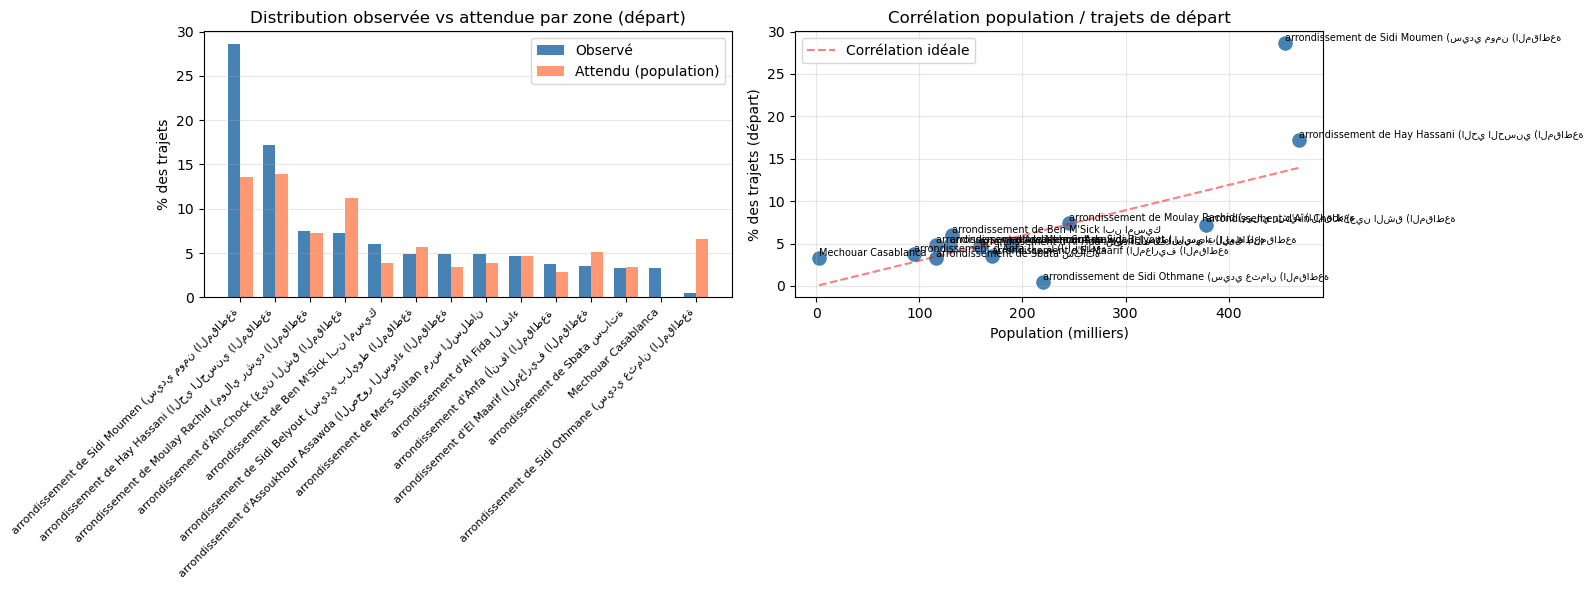


✅ VALIDATION OK — 11/14 zones dans ratio acceptable [0.5, 2.0]


In [14]:
import matplotlib.pyplot as plt

# Échantillon pour validation rapide
df_val = df_curated.limit(500).cache()
n_total = df_val.count()
print(f"Échantillon de validation : {n_total} trajets")

# Distribution observée
dist_obs = df_val \
    .groupBy("origin_zone_id", "origin_zone_name") \
    .count() \
    .orderBy("count", ascending=False) \
    .toPandas()
dist_obs["pct_observed"] = dist_obs["count"] / dist_obs["count"].sum()

# Distribution attendue (population)
pop_df = pd.DataFrame([
    {"origin_zone_name": z["zone_name"], "population": z["population"]}
    for z in zones_info
])
pop_df["pct_expected"] = pop_df["population"] / pop_df["population"].sum()

dist_merged = dist_obs.merge(pop_df, on="origin_zone_name", how="left")
dist_merged["ratio"] = (dist_merged["pct_observed"] / dist_merged["pct_expected"]).round(2)

print(f"\n{'Zone':<25} {'Observé':>9} {'Attendu':>9} {'Ratio':>7}")
print("-" * 55)
for _, r in dist_merged.iterrows():
    flag = "✅" if 0.5 <= r["ratio"] <= 2.0 else "⚠️ "
    print(f"{flag} {r['origin_zone_name']:<23} "
          f"{r['pct_observed']:>8.3f} {r['pct_expected']:>9.3f} {r['ratio']:>7.2f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top = dist_merged.dropna().sort_values("pct_observed", ascending=False).head(14)
x, w = range(len(top)), 0.35

axes[0].bar([i - w/2 for i in x], top["pct_observed"] * 100,
            width=w, label="Observé", color="steelblue")
axes[0].bar([i + w/2 for i in x], top["pct_expected"].fillna(0) * 100,
            width=w, label="Attendu (population)", color="coral", alpha=0.8)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(top["origin_zone_name"], rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("% des trajets")
axes[0].set_title("Distribution observée vs attendue par zone (départ)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

valid = dist_merged.dropna(subset=["population"])
axes[1].scatter(valid["population"] / 1000, valid["pct_observed"] * 100,
                color="steelblue", s=90)
for _, row in valid.iterrows():
    axes[1].annotate(row["origin_zone_name"],
                     (row["population"] / 1000, row["pct_observed"] * 100),
                     fontsize=7, ha="left", va="bottom")
x_line = [valid["population"].min()/1000, valid["population"].max()/1000]
y_line = [valid["pct_expected"].min()*100, valid["pct_expected"].max()*100]
axes[1].plot(x_line, y_line, "r--", alpha=0.5, label="Corrélation idéale")
axes[1].set_xlabel("Population (milliers)")
axes[1].set_ylabel("% des trajets (départ)")
axes[1].set_title("Corrélation population / trajets de départ")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/home/jovyan/distribution_zones.png", dpi=120, bbox_inches="tight")
plt.show()

zones_ok    = ((dist_merged["ratio"] >= 0.5) & (dist_merged["ratio"] <= 2.0)).sum()
zones_total = len(dist_merged.dropna(subset=["ratio"]))
VALIDATION_OK = zones_ok >= zones_total * 0.7
print(f"\n{'✅ VALIDATION OK' if VALIDATION_OK else '❌ VALIDATION ÉCHOUÉE'} "
      f"— {zones_ok}/{zones_total} zones dans ratio acceptable [0.5, 2.0]")
if not VALIDATION_OK:
    print("⚠️  Ajuster les poids population dans la cellule 3 avant de continuer.")


## 🗺️ CELLULE 12 — Heatmap + visualisation trajets snappés

In [ ]:
from folium.plugins import HeatMap
import os

def add_casa_boundary(m, casa_polygon, color="black"):
    polys = casa_polygon.geoms if casa_polygon.geom_type == "MultiPolygon" else [casa_polygon]
    for poly in polys:
        folium.PolyLine(
            [(lat, lon) for lon, lat in poly.exterior.coords],
            color=color, weight=3, opacity=0.9
        ).add_to(m)
    return m

df_starts = df_val.select("snapped_polyline", "origin_zone_name").toPandas()
heat_data = []
for _, row in df_starts.iterrows():
    try:
        # 🔧 INVERSER les coordonnées pour Folium
        lon, lat = json.loads(row["snapped_polyline"])[0]
        heat_data.append([lat, lon])  # [lat, lon] pour Folium
    except:
        continue

m_heat = folium.Map(location=[33.5731, -7.5898], zoom_start=12)
HeatMap(heat_data, min_opacity=0.3, radius=14, blur=16,
        gradient={0.2: "blue", 0.5: "lime", 0.8: "orange", 1.0: "red"}).add_to(m_heat)
folium.GeoJson(
    gdf_arr[[NAME_COL, "geometry"]].to_json(),
    style_function=lambda x: {"fillColor": "transparent", "color": "white",
                               "weight": 1.5, "opacity": 0.7},
    tooltip=folium.GeoJsonTooltip(fields=[NAME_COL], aliases=["Arrondissement"])
).add_to(m_heat)
m_heat = add_casa_boundary(m_heat, CASA_POLYGON)

os.makedirs("/home/jovyan/outputs", exist_ok=True)
m_heat.save("/home/jovyan/outputs/heatmap_dispersion.html")
print(f"✅ Heatmap — {len(heat_data)} points de départ")
m_heat

✅ Heatmap — 430 points de départ


In [ ]:
# ── Visualisation de X trajets snappés ──────────────────────────────────
NB_TRAJETS_A_AFFICHER = 100
NB_LIGNES_A_CHARGER = 300

rows_snap = df_val.select("snapped_polyline", "origin_zone_name", "dest_zone_name") \
                  .limit(NB_LIGNES_A_CHARGER).collect()

m_snap = folium.Map(location=[33.5731, -7.5898], zoom_start=12)

colors = ["red","blue","green","purple","orange",
          "darkred","cadetblue","pink","gray","black",
          "darkblue","darkgreen","beige","lightred","lightblue",
          "cyan","magenta","yellow","brown","lime","teal","navy","coral"]

count = 0
for i, row in enumerate(rows_snap):
    if count >= NB_TRAJETS_A_AFFICHER:
        break
    try:
        route_raw = json.loads(row["snapped_polyline"])
        if len(route_raw) < 2:
            continue
        # 🔧 INVERSER les coordonnées pour Folium : [[lat, lon], ...]
        route = [[lat, lon] for lon, lat in route_raw]
        
        folium.PolyLine(
            route, color=colors[count % len(colors)], weight=4, opacity=0.85,
            tooltip=f"Trajet {count} | {row['origin_zone_name']} → {row['dest_zone_name']}"
        ).add_to(m_snap)
        folium.CircleMarker(route[0], radius=5, color="green", fill=True,
                            popup=f"Départ : {row['origin_zone_name']}").add_to(m_snap)
        folium.CircleMarker(route[-1], radius=5, color="red", fill=True,
                            popup=f"Arrivée : {row['dest_zone_name']}").add_to(m_snap)
        count += 1
    except:
        continue

print(f"✅ {count} trajets affichés (sur {len(rows_snap)} chargés)")

m_snap = add_casa_boundary(m_snap, CASA_POLYGON)
m_snap.save("/home/jovyan/outputs/snap_routes_final.html")
print(f"✅ {count} trajets snappés affichés")
m_snap

✅ 100 trajets affichés (sur 300 chargés)
✅ 100 trajets snappés affichés


## 💾 CELLULE 13 — Sauvegarde `curated/porto-trips/` (Parquet)

⚠️ **Exécuter seulement si `VALIDATION_OK = True` en cellule 11.**

In [17]:
VALIDATION_OK = True  # forcer pour test avec petit échantillon
print("⚠️  Validation forcée — échantillon trop petit (10 trajets)")

OUTPUT_PATH = "s3a://curated/porto-trips/"

df_curated \
    .write \
    .mode("overwrite") \
    .partitionBy("year_month") \
    .parquet(OUTPUT_PATH)

print(f"✅ Dataset sauvegardé dans {OUTPUT_PATH}")
print("\nColonnes stockées :")
for c in df_curated.columns:
    print(f"  - {c}")

print("""
📌 Colonnes ajoutées en Semaine 5 (ETL Spark) :
   - arrondissement_id  (spatial join GeoJSON précis)
   - zone_type          (residential / commercial / transit_hub)

📌 Features ajoutées en Semaine 6 (ML) :
   - hour_of_day, day_of_week, is_weekend, is_friday
   - demand_lag_1d, demand_lag_7d, rolling_7d_mean
   - is_raining, temperature_bucket  (Open-Meteo API)
   - zone_population_density
""")


⚠️  Validation forcée — échantillon trop petit (10 trajets)
✅ Dataset sauvegardé dans s3a://curated/porto-trips/

Colonnes stockées :
  - trip_id
  - taxi_id
  - timestamp
  - call_type
  - day_type
  - snapped_polyline
  - trip_duration_sec
  - origin_zone_id
  - origin_zone_name
  - dest_zone_id
  - dest_zone_name
  - year_month

📌 Colonnes ajoutées en Semaine 5 (ETL Spark) :
   - arrondissement_id  (spatial join GeoJSON précis)
   - zone_type          (residential / commercial / transit_hub)

📌 Features ajoutées en Semaine 6 (ML) :
   - hour_of_day, day_of_week, is_weekend, is_friday
   - demand_lag_1d, demand_lag_7d, rolling_7d_mean
   - is_raining, temperature_bucket  (Open-Meteo API)
   - zone_population_density

